  [springpot] step     0 | -ELBO 1.9571 | alpha=0.499 | wait 0
  [springpot] step   200 | -ELBO 0.9206 | alpha=0.775 | wait 0
  [springpot] step   400 | -ELBO 0.3961 | alpha=0.913 | wait 0
  [springpot] step   600 | -ELBO 0.0849 | alpha=0.961 | wait 0
  [springpot] step   800 | -ELBO 0.0004 | alpha=0.979 | wait 0
  [springpot] step  1000 | -ELBO -0.0192 | alpha=0.987 | wait 1
  [springpot] step  1200 | -ELBO -0.0278 | alpha=0.990 | wait 0
  [springpot] step  1400 | -ELBO -0.0327 | alpha=0.993 | wait 3
  [springpot] step  1600 | -ELBO -0.0358 | alpha=0.994 | wait 6
  [springpot] step  1800 | -ELBO -0.0382 | alpha=0.995 | wait 1
  [springpot] step  2000 | -ELBO -0.0400 | alpha=0.996 | wait 6
  [springpot] step  2200 | -ELBO -0.0413 | alpha=0.997 | wait 18
  [springpot] step  2400 | -ELBO -0.0424 | alpha=0.997 | wait 11
  [springpot] step  2600 | -ELBO -0.0433 | alpha=0.997 | wait 16
  [springpot] step  2800 | -ELBO -0.0440 | alpha=0.998 | wait 14
  [springpot] step  3000 | -ELBO -0.0445 

PosixPath('adhesive_scottblair_fit_steady')

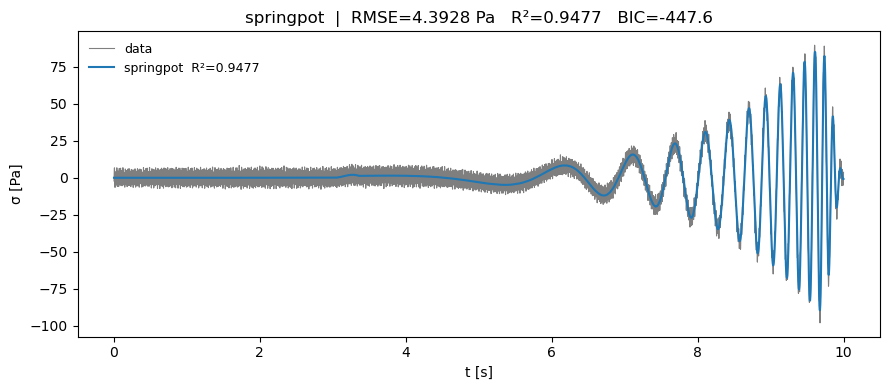

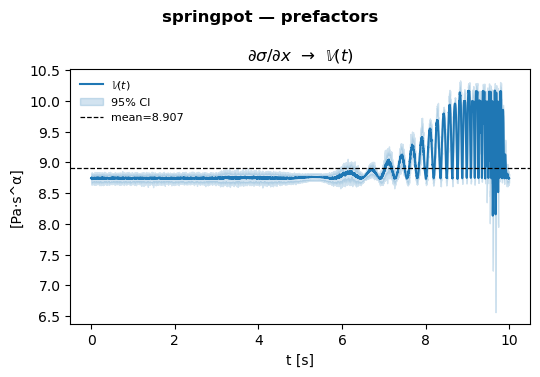

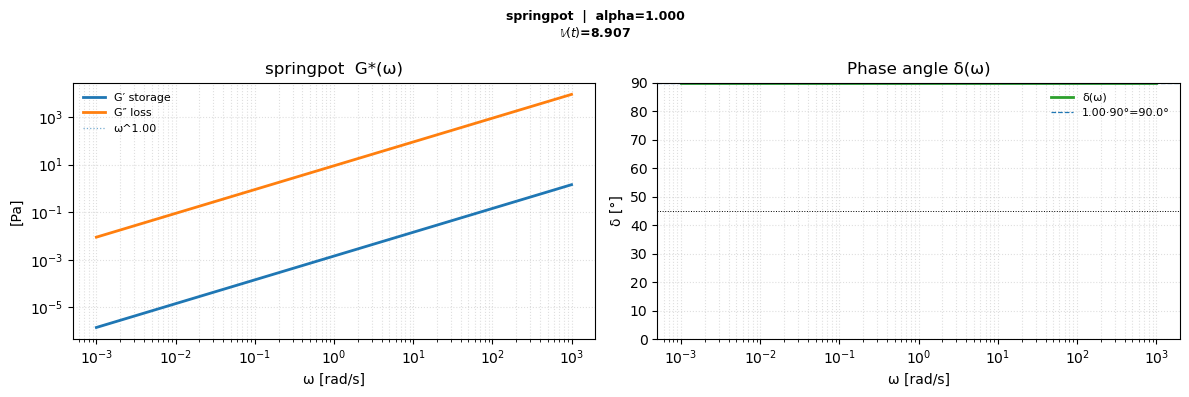

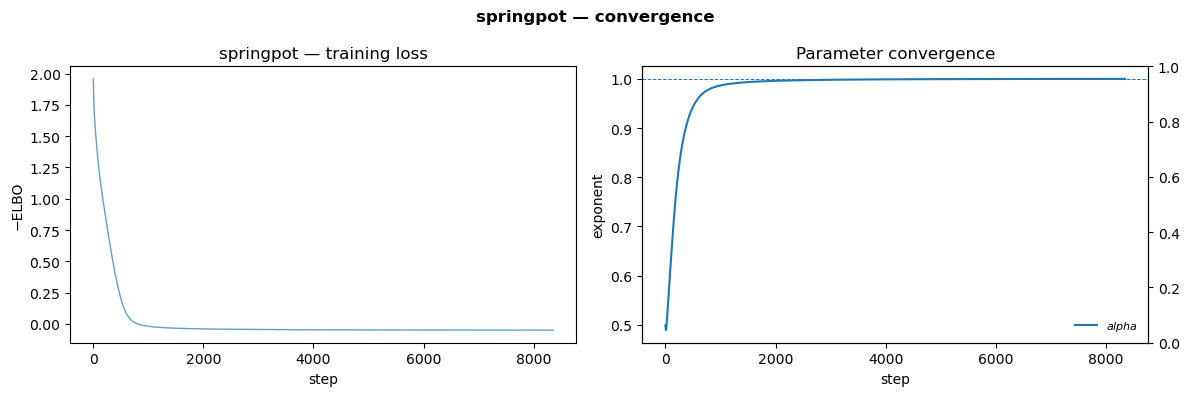

In [2]:
from rheogp import SPGP
from rheogp.utils import compare_models
import pandas as pd
import numpy as np
from pathlib import Path

file_path = Path.cwd().parent / "demos" / "data" / "adhesive_chirp_189.859.xlsx"
df = pd.read_excel(file_path)

omega_min = 0.01
omega_max = 2000

t = df.iloc[:, 0].values.astype(np.float32)  
strain = df.iloc[:, 1].values.astype(np.float32)
stress = df.iloc[:, 2].values.astype(np.float32) 

model = SPGP(model="springpot", kernel="rbf",
                                           #   (keep kernel="rbf" for identical-to-before behavior)
             convolution="causal",         # NEW: or "steady" if your chirp is windowed
             quadrature="exact",           # NEW default (use "left" to reproduce v0.1 numbers)
             inducing_points=300, learning_rate=0.005, learning_rate_physics=0.005, patience=500,
             omega_min=0.001, omega_max=1000, n_epochs=20000)

model.fit(t, strain, stress)

print(model.summary())           # BIC, RMSE, R², all params with CI
sigma_pred, sigma_std = model.predict(strain, return_std=True)

model.plot_fit()
model.plot_prefactors()
model.plot_Gstar()
model.plot_convergence()

# NEW: everything as plain numpy, for your own paper figures
res = model.results()
res.t, res.prediction, res.prediction_std   # fit ± σ
res.features, res.feature_names             # physical features x_i(t)
#res.sensitivities["V"]["mean"]             # time-resolved prefactor + CI bands
res.omega, res.Gp, res.Gdp                  # model G', G''
res.metrics["aic"], res.metrics["bic"]      # information criteria
res.save("adhesive_scottblair_fit_steady")            # → .npz + .json, reload with FitResult.load()

In [ ]:
sigma_pred = model.predict(strain)
sigma_pred, sigma_std = model.predict(strain, return_std=True)

model.plot_fit()
model.plot_prefactors()          # V(t) and G(t) with 95% CI
model.plot_Gstar(add_fft=True)               # G′, G″, phase angle
model.plot_convergence()

In [11]:
# --- Add GP input features: standardized (what GP sees) and raw (physical convolution) ---
import matplotlib.pyplot as plt

def _compute_raw_features(model):
    """
    Raw (unstandardized) convolution features x(t) for common models:
    Springpot, Fractional Maxwell (full, covers FMG/FML via params), Fractional Kelvin–Voigt (full).
    Also supports FKVS/FKVD second branch (γ or γ̇) when those kernels are used.
    Returns: t (N,), X_raw (N, d), labels (list[str])
    """
    import numpy as np
    import torch
    import rheogp.kernels as rk

    phys = model.gp_model_.phys
    t = model.t_.astype(np.float64)
    dt = float(np.median(np.diff(t)))
    gamma = torch.tensor(model.strain_, dtype=torch.float64)

    # Common helpers
    s = rk._lag_vector(gamma.shape[0], dt, device=gamma.device, dtype=gamma.dtype)
    gd = rk._gamma_dot(gamma, dt)  # γ̇(t)

    X_cols, labels = [], []

    # Springpot
    if isinstance(phys, rk.SpringpotKernel):
        alpha = torch.tensor(phys.alpha.item(), dtype=gamma.dtype)
        K = rk._caputo_kernel(s, alpha)
        x = rk._fft_convolve(gd, K, dt)
        X_cols.append(x.detach().cpu().numpy()); labels.append(r"D$^{\alpha}[\gamma]$ (s$^{-\alpha}$)")

    # Fractional Maxwell (full; FMG/FML via parameters)
    elif isinstance(phys, rk.FractionalMaxwellKernel):
        alpha = torch.tensor(phys.alpha.item(), dtype=gamma.dtype)
        beta  = torch.tensor(phys.beta.item(),  dtype=gamma.dtype)
        tau_c = torch.tensor(phys.tau_c.item(), dtype=gamma.dtype)
        K = rk._fmm_kernel(s, alpha, beta, tau_c)
        x = rk._fft_convolve(gd, K, dt)
        X_cols.append(x.detach().cpu().numpy()); labels.append(r"K$_{\mathrm{FMM}} \star \dot{\gamma}$ (–)")

    # Fractional Kelvin–Voigt (full)
    elif isinstance(phys, rk.FractionalKelvinVoigtKernel):
        alpha = torch.tensor(phys.alpha.item(), dtype=gamma.dtype)
        beta  = torch.tensor(phys.beta.item(),  dtype=gamma.dtype)
        Ka = rk._caputo_kernel(s, alpha)
        Kb = rk._caputo_kernel(s, beta)
        xa = rk._fft_convolve(gd, Ka, dt)
        xb = rk._fft_convolve(gd, Kb, dt)
        X_cols.append(xa.detach().cpu().numpy()); labels.append(r"D$^{\alpha}[\gamma]$ (s$^{-\alpha}$)")
        X_cols.append(xb.detach().cpu().numpy()); labels.append(r"D$^{\beta}[\gamma]$ (s$^{-\beta}$)")

    # Fractional Kelvin–Voigt S (springpot ∥ spring): [D^αγ, γ]
    elif isinstance(phys, rk.FKVSKernel):
        alpha = torch.tensor(phys.alpha.item(), dtype=gamma.dtype)
        Ka = rk._caputo_kernel(s, alpha)
        xa = rk._fft_convolve(gd, Ka, dt)           # D^α[γ]
        x0 = gamma                                  # γ
        X_cols.append(xa.detach().cpu().numpy()); labels.append(r"D$^{\alpha}[\gamma]$ (s$^{-\alpha}$)")
        X_cols.append(x0.detach().cpu().numpy());  labels.append(r"$\gamma$ (–)")

    # Fractional Kelvin–Voigt D (dashpot ∥ springpot): [D^βγ, γ̇]
    elif isinstance(phys, rk.FKVDKernel):
        beta = torch.tensor(phys.beta.item(), dtype=gamma.dtype)
        Kb = rk._caputo_kernel(s, beta)
        xb = rk._fft_convolve(gd, Kb, dt)           # D^β[γ]
        x1 = gd                                     # γ̇
        X_cols.append(xb.detach().cpu().numpy()); labels.append(r"D$^{\beta}[\gamma]$ (s$^{-\beta}$)")
        X_cols.append(x1.detach().cpu().numpy()); labels.append(r"$\dot{\gamma}$ (s$^{-1}$)")

    # Maxwell (classical): [exp kernel ★ γ̇]
    elif isinstance(phys, rk.MaxwellKernel):
        tau_c = torch.tensor(phys.tau_c.item(), dtype=gamma.dtype)
        Km = rk._maxwell_kernel(s, tau_c)
        x = rk._fft_convolve(gd, Km, dt)
        X_cols.append(x.detach().cpu().numpy()); labels.append(r"exp kernel $\star \dot{\gamma}$ (–)")

    else:
        # Fallback: use whatever compute_x() returned (but that is standardized)
        raise NotImplementedError(f"Raw features not implemented for {type(phys).__name__}")

    X_raw = np.vstack(X_cols).T  # (N, d)
    return t, X_raw, labels

# Standardized GP inputs (unitless)
X_norm = model.gp_model_.compute_x().detach().cpu().numpy()  # (N, d)

# Raw features (with physical units; see labels)
try:
    X_time, X_raw, X_labels = _compute_raw_features(model)
except Exception as e:
    print(f"Warning: could not compute raw features: {e}")
    X_time, X_raw, X_labels = model.t_, None, []

# Optional: quick figure overlaying strain on each raw feature
try:
    if X_raw is not None and X_raw.size:
        rows = X_raw.shape[1]
        fig_feat, ax = plt.subplots(rows, 1, figsize=(7, 2.6 * rows), sharex=True)
        if rows == 1: ax = [ax]
        for j in range(rows):
            ax[j].plot(X_time, X_raw[:, j], lw=1.5, label=X_labels[j] if j < len(X_labels) else f"x{j}")
            ax[j].set_ylabel(X_labels[j] if j < len(X_labels) else f"x{j}")
            ax2 = ax[j].twinx()
            ax2.plot(model.t_, model.strain_, 'k--', lw=1.1, alpha=0.8, label="γ(t)")
            ax2.set_ylabel("γ (–)")
            # Combined legend
            l1, lab1 = ax[j].get_legend_handles_labels()
            l2, lab2 = ax2.get_legend_handles_labels()
            ax[j].legend(l1 + l2, lab1 + lab2, loc="best")
            ax[j].grid(alpha=0.2)
        ax[-1].set_xlabel("t (s)")
        fig_feat.tight_layout()
        fig_feat.savefig("features_raw.pdf", bbox_inches="tight")
        fig_feat.savefig("features_raw.png", dpi=300, bbox_inches="tight")
        plt.close(fig_feat)
except Exception as e:
    print(f"Warning: feature plot failed: {e}")

# ---------- Save results (arrays + metadata) and figures ----------
from pathlib import Path
import numpy as np
import json
import matplotlib.pyplot as plt

# 6) Save arrays (compressed NPZ)
omega_curve = np.logspace(np.log10(model.omega_min),
                          np.log10(model.omega_max), model.n_omega)
scalar_pf   = {k: v["scalar_mean"] for k, v in model.prefactors_.items()}
Gp_curve, Gdp_curve = model.gp_model_.phys.Gstar(omega_curve, scalar_pf)

# 2) FFT dots (no plotting)
omega_fft, Gp_fft, Gdp_fft = model._chirp_fft_Gstar(eps=1e-12)
mask = (omega_fft >= model.omega_min) & (omega_fft <= model.omega_max)
omega_fft, Gp_fft, Gdp_fft = omega_fft[mask], Gp_fft[mask], Gdp_fft[mask]

# 3) Prefactors summary + (optional) samples
pref_summary = {
    name: {
        "mean":    info["mean"].tolist(),
        "lower":   info["lower"].tolist(),
        "upper":   info["upper"].tolist(),
        "scalar_mean":  info["scalar_mean"],
        "scalar_lower": info["scalar_lower"],
        "scalar_upper": info["scalar_upper"],
    }
    for name, info in model.prefactors_.items()
}

# Optional: include posterior samples (can be large)
include_samples = True
if include_samples:
    for name, info in model.prefactors_.items():
        pref_summary[name]["samples"] = info["samples"]  # keep as ndarray for .npz

# 4) Serializable metadata
meta = {
    "model_name": model.model_name,
    "kernel_name": model.kernel_name,
    "omega_min": model.omega_min,
    "omega_max": model.omega_max,
    "n_omega": model.n_omega,
    "phys_params": model.gp_model_.phys.named_phys_params(),
    "metrics": model.metrics_,
}

# 5) Training history (loss and tracked physics params)
history = {
    "loss": model.history_.get("loss", []),
    "params": model.history_.get("params", {}),
}

# 5) Save arrays in a compressed NPZ; save metadata (and prefactors summary) as JSON
out_dir = Path("outputs_adhesive")
out_dir.mkdir(parents=True, exist_ok=True)

arrays = dict(
    time=model.t_,
    strain=model.strain_,
    stress=model.stress_,
    pred=sigma_pred,
    pred_std=sigma_std,
    omega_curve=omega_curve,
    Gp_curve=Gp_curve,
    Gdp_curve=Gdp_curve,
    omega_fft=omega_fft,
    Gp_fft=Gp_fft,
    Gdp_fft=Gdp_fft,
    # Added: features
    X_time=X_time if X_raw is not None else model.t_,
    X_norm=X_norm,                          # standardized GP inputs (unitless)
    X_raw=X_raw if X_raw is not None else np.array([]),  # raw features (physical units)
)

# Optional: add prefactor samples (already in your code when include_samples=True)
if include_samples:
    for name, info in model.prefactors_.items():
        arrays[f"pref_{name}_samples"] = info["samples"]
        
np.savez_compressed(out_dir / "rheogp_arrays.npz", **arrays)

# 7) Save metadata (JSON)
meta = {
    "model_name": model.model_name,
    "kernel_name": model.kernel_name,
    "inducing_points": model.inducing_points,
    "learning_rate": model.learning_rate,
    "omega_min": model.omega_min,
    "omega_max": model.omega_max,
    "n_omega": model.n_omega,
    "phys_params": {k: float(v) for k, v in model.gp_model_.phys.named_phys_params().items()},  # Ensure floats
    "metrics": {k: float(v) for k, v in model.metrics_.items() if not isinstance(v, dict)},  # Ensure floats
    "prefactors": {
        name: {
            "mean": info["mean"] if isinstance(info["mean"], list) else info["mean"].tolist(),
            "lower": info["lower"] if isinstance(info["lower"], list) else info["lower"].tolist(),
            "upper": info["upper"] if isinstance(info["upper"], list) else info["upper"].tolist(),
            "scalar_mean": float(info["scalar_mean"]),
            "scalar_lower": float(info["scalar_lower"]),
            "scalar_upper": float(info["scalar_upper"]),
        }
        for name, info in pref_summary.items()
    },
    "history": {
        "loss": list(history["loss"]),
        "tracked_params": {
            k: list(v) for k, v in history["params"].items()  # Ensure lists
        },
    },
    "X_labels": list(X_labels) if isinstance(X_labels, np.ndarray) else X_labels,  # Convert ndarray to list
}


with open(out_dir / "rheogp_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

